#### Imports

In [ ]:
from huggingface_hub import login
login()


In [151]:
import pandas as pd
from datasets import load_dataset

import seaborn as sns
import matplotlib.pyplot as plt

from datasets import Value

import numpy as np
import shap

pd.options.mode.chained_assignment = None

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

In [173]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, roc_curve

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import SVC

In [68]:
import warnings
import os

os.environ["PYTHONWARNINGS"] = "ignore"

def fxn():
    warnings.warn("deprecated", DeprecationWarning)


with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    fxn()

#### Data Load

In [ ]:
raw_stream = load_dataset("sanjaycusat/telco-customer-churn3", streaming=True, split="train") #Splitting to prevent data leakage

#Read more about the dataset here: https://www.kaggle.com/datasets/blastchar/telco-customer-churn

In [6]:
print(raw_stream) #The data is now an IterableDataset object, which can be iterated over to access the data in a streaming fashion.

IterableDataset({
    features: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
    num_shards: 1
})


In [10]:
len(raw_stream.features)

21

#### Schema Analysis

In [7]:
print("----DATA PIPELINE SCHEMA----")
for column_name, data_type in raw_stream.features.items():
    print(f"{column_name}: {data_type}")

----DATA PIPELINE SCHEMA----
customerID: Value('string')
gender: Value('string')
SeniorCitizen: Value('int64')
Partner: Value('string')
Dependents: Value('string')
tenure: Value('int64')
PhoneService: Value('string')
MultipleLines: Value('string')
InternetService: Value('string')
OnlineSecurity: Value('string')
OnlineBackup: Value('string')
DeviceProtection: Value('string')
TechSupport: Value('string')
StreamingTV: Value('string')
StreamingMovies: Value('string')
Contract: Value('string')
PaperlessBilling: Value('string')
PaymentMethod: Value('string')
MonthlyCharges: Value('float64')
TotalCharges: Value('string')
Churn: Value('string')


In [24]:
print("----TOP 5 ROWS----")
top_5_rows = raw_stream.take(5)

df_top_5_rows = pd.DataFrame(top_5_rows)
df_top_5_rows

----TOP 5 ROWS----


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


#### Missing Value and Statistical Analysis

In [102]:
def missing_values_check(df):
    metrics = {
        "total_rows": 0,
        "missing_values": {col: 0 for col in df.features},
        }

    #Streaming through the dataset to compute metrics
    #Single pass loop
    for row in df:
        metrics["total_rows"]+= 1
        for col in df.features: 
            value = row[col]

            if value is None or str(value).strip().lower() in ["", "na", "nan", "null"]:
                metrics["missing_values"][col] += 1

    #print(metrics)

    print("\n---STREAMING DIAGNOSTICS COMPLETED---")
    print(f"Total Dataset Rows Scaled: {metrics['total_rows']}")
    print("Missing Values Found Per Column:")
    for col, count in metrics["missing_values"].items():
        if count > 0:
            print(f"\t{col}: {count} missing rows")

missing_values_check(raw_stream)



---STREAMING DIAGNOSTICS COMPLETED---
Total Dataset Rows Scaled: 7043
Missing Values Found Per Column:
	TotalCharges: 11 missing rows


In [ ]:
print("---STREAMING AUDIT: ISOLATING MISSING TOTALCHARGES---")

missing_sample_count = 0

for row in raw_stream:
    val = row['TotalCharges']
    if val is None or str(val).strip().lower() in ["", "na", "nan", "null"]:
                missing_sample_count += 1
                print(f"CustomerID: {row['customerID']}, TotalCharges: {val}, MonthlyCharges: {row['MonthlyCharges']}, tenure: {row['tenure']}, Churn: {row['Churn']}")
                if missing_sample_count >= 11:
                        break

print(f"\nAudit complete. Total verified rows: {missing_sample_count}")

# This shows that the missing TotalCharges values are all for customers with tenure=0, 
# which is expected since they haven't been charged yet. This is a data quality issue that can be handled in preprocessing.
# The MonthlyCharges are not blank because that is the contract rate, which is known at the time of signup. 

---STREAMING AUDIT: ISOLATING MISSING TOTALCHARGES---
CustomerID: 4472-LVYGI, TotalCharges:  , MonthlyCharges: 52.55, tenure: 0, Churn: No
CustomerID: 3115-CZMZD, TotalCharges:  , MonthlyCharges: 20.25, tenure: 0, Churn: No
CustomerID: 5709-LVOEQ, TotalCharges:  , MonthlyCharges: 80.85, tenure: 0, Churn: No
CustomerID: 4367-NUYAO, TotalCharges:  , MonthlyCharges: 25.75, tenure: 0, Churn: No
CustomerID: 1371-DWPAZ, TotalCharges:  , MonthlyCharges: 56.05, tenure: 0, Churn: No
CustomerID: 7644-OMVMY, TotalCharges:  , MonthlyCharges: 19.85, tenure: 0, Churn: No
CustomerID: 3213-VVOLG, TotalCharges:  , MonthlyCharges: 25.35, tenure: 0, Churn: No
CustomerID: 2520-SGTTA, TotalCharges:  , MonthlyCharges: 20.0, tenure: 0, Churn: No
CustomerID: 2923-ARZLG, TotalCharges:  , MonthlyCharges: 19.7, tenure: 0, Churn: No
CustomerID: 4075-WKNIU, TotalCharges:  , MonthlyCharges: 73.35, tenure: 0, Churn: No
CustomerID: 2775-SEFEE, TotalCharges:  , MonthlyCharges: 61.9, tenure: 0, Churn: No

Audit complet

In [ ]:
# This is not a wise choice as we will be building a pipeline later and that will update the stream after all changes at once.


#Impute all the missing TotalCharges values with 0.0 

'''
def fix_missing_values(row):
    val = row['TotalCharges']
    if val is None or str(val).strip().lower() in ["", "na", "nan", "null"]:
        row['TotalCharges'] = 0.0
    else:
        row['TotalCharges'] = float(val)
    return row
'''

#Copying the features from the raw_stream to avoid Features:Unknown. 
# Expected behavior of Hugging Face's lazy streaming architecture as it cannot guarantee what the final columns or data types look like until the data actually flows through the pipe
# updated_features = raw_stream.features.copy()
# updated_features['TotalCharges'] = Value(dtype='float64') #Since we explicitly changed this

# clean_stream = raw_stream.map(fix_missing_values, features=updated_features)
# missing_values_check(clean_stream) 

In [ ]:
print("---Welford’s Algorithm for Streaming Mean and Variance---")
#This algorithm prevents numerical instability (catastrophic cancellation)
#If you try to compute running variance using the standard textbook shortcut formula, rounding errors from working with massive numbers can result in floating-point inaccuracies, sometimes even generating impossible negative variances. Welford's algorithm works purely with small relative differences, keeping the math incredibly precise even over billions of streaming rows.

print("Core Components: \n\tn: The count of data points seen so far.\n\tx_bar_{n}: The current running mean after seeing n items.\n\tM_{2,n}: The running sum of the squares of differences from the mean (historically called the aggregate squared distance). ")
print("\n1. Compute the error between the new value and the current mean: \n\tdelta = x_{n} - x_bar_{n-1}\n2. Update the running mean: \n\tx_bar_{n} = x_bar_{n-1} + delta/n\n3. Update the delta: \n\tdelta_new = x_{n} - x_bar_{n}\n4. Update the sum of squares: \n\tM_{2,n} = M_{2,n-1} + delta * delta_new")

#Tenure, MonthlyCharges, and TotalCharges are numeric columns in the dataset.

print("\n--- STREAMING STATISTICAL OUTLIER BOUNDARIES ---")
cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

for c in cols:
    count = 0
    mean = 0.0
    M2 = 0.0 # Used to calculate variance dynamically
    for row in raw_stream:
        try: 
            val = float(row[c])
        except (ValueError, TypeError):
            continue
        count += 1
        delta = val - mean
        mean += delta / count
        delta2 = val - mean
        M2 += delta * delta2

    if count > 1:
        variance = M2/(count-1)
        std_dev = variance ** 0.5
        print(f"{c}: \n\tRunning Mean = {mean:.2f}, \n\tRunning Variance = {variance:.2f}, \n\tRunning Standard Deviation = {std_dev:.2f}, \n\tOutlier Threshold (3 Std Devs above Mean) = > {mean + (3 * std_dev):.2f}")
    else:
        print("Not enough numerical data points to compute streaming statistics.")

---Welford’s Algorithm for Streaming Mean and Variance---
Core Components: 
	n: The count of data points seen so far.
	x_bar_{n}: The current running mean after seeing n items.
	M_{2,n}: The running sum of the squares of differences from the mean (historically called the aggregate squared distance). 

1. Compute the error between the new value and the current mean: 
	delta = x_{n} - x_bar_{n-1}
2. Update the running mean: 
	x_bar_{n} = x_bar_{n-1} + delta/n
3. Update the delta: 
	delta_new = x_{n} - x_bar_{n}
4. Update the sum of squares: 
	M_{2,n} = M_{2,n-1} + delta * delta_new

--- STREAMING STATISTICAL OUTLIER BOUNDARIES ---
tenure: 
	Running Mean = 32.37, 
	Running Variance = 603.17, 
	Running Standard Deviation = 24.56, 
	Outlier Threshold (3 Std Devs above Mean) = > 106.05
MonthlyCharges: 
	Running Mean = 64.76, 
	Running Variance = 905.41, 
	Running Standard Deviation = 30.09, 
	Outlier Threshold (3 Std Devs above Mean) = > 155.03
TotalCharges: 
	Running Mean = 2283.30, 
	Runni

#### Visualization after Reservoir Sampling

In [80]:
print("---DIAGNOSTIC RESERVOIR SAMPLING---")
#Stream a clean, random subset into an isolated, small Pandas DataFrame strictly for the data scientist's visualization notebook

visualization_df = pd.DataFrame(list(raw_stream.take(2000)))

visualization_df['MonthlyCharges'] = pd.to_numeric(visualization_df['MonthlyCharges'], errors='coerce')
visualization_df['TotalCharges'] = pd.to_numeric(visualization_df['TotalCharges'], errors='coerce')
visualization_df['tenure'] = pd.to_numeric(visualization_df['tenure'], errors='coerce')

---DIAGNOSTIC RESERVOIR SAMPLING---


/Users/mariapratyusha/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/mariapratyusha/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/mariapratyusha/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


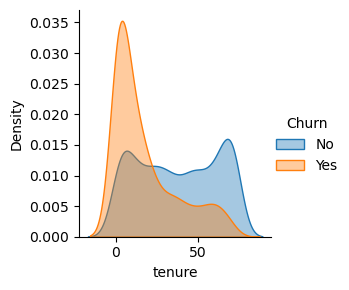

In [ ]:
g = sns.FacetGrid(visualization_df,hue='Churn')
g = g.map(sns.kdeplot,'tenure',fill=True,alpha=0.4)                      
g.add_legend()

# The plot reveals that the company is losing most of its customers right after they sign up.

Text(0.5, 1.0, 'Relationship between Churn and Tenure')

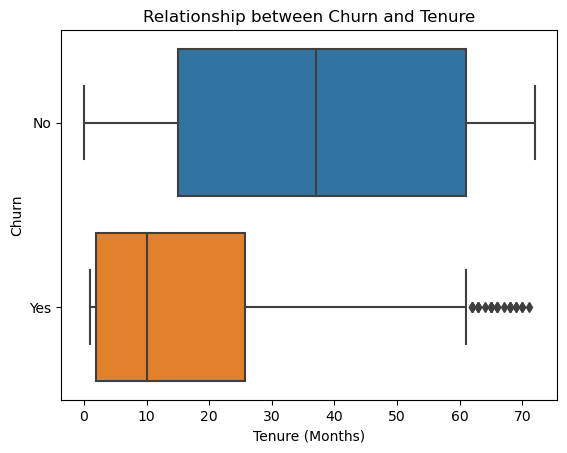

In [87]:
sns.boxplot(data=visualization_df, x="tenure", y="Churn")
plt.ylabel('Churn')
plt.xlabel('Tenure (Months)')
plt.title('Relationship between Churn and Tenure')

/Users/mariapratyusha/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/mariapratyusha/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/mariapratyusha/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


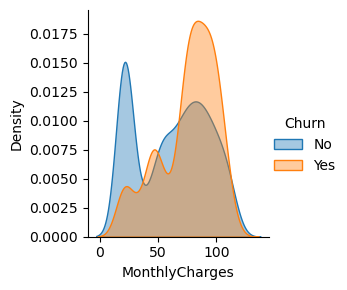

In [ ]:
g = sns.FacetGrid(visualization_df, hue='Churn')
g = g.map(sns.kdeplot, 'MonthlyCharges', fill=True, alpha=0.4)
g.add_legend()

# The plot reveals that the company is losing most of its customers when the monthly charges are higher than $60.

Text(0.5, 1.0, 'Relationship between Churn and Monthly Charges')

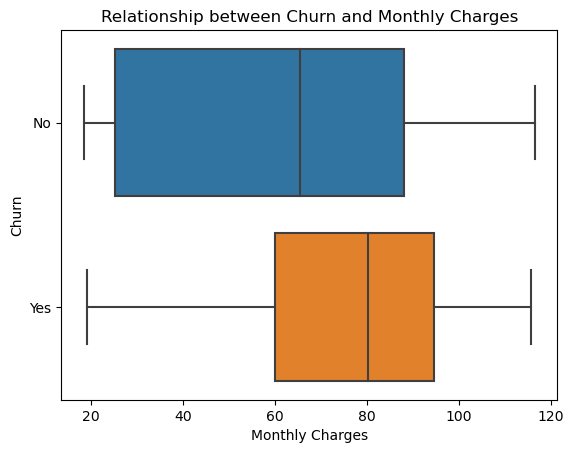

In [88]:
sns.boxplot(data=visualization_df, x="MonthlyCharges", y="Churn")
plt.ylabel('Churn')
plt.xlabel('Monthly Charges')
plt.title('Relationship between Churn and Monthly Charges')

/Users/mariapratyusha/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/mariapratyusha/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


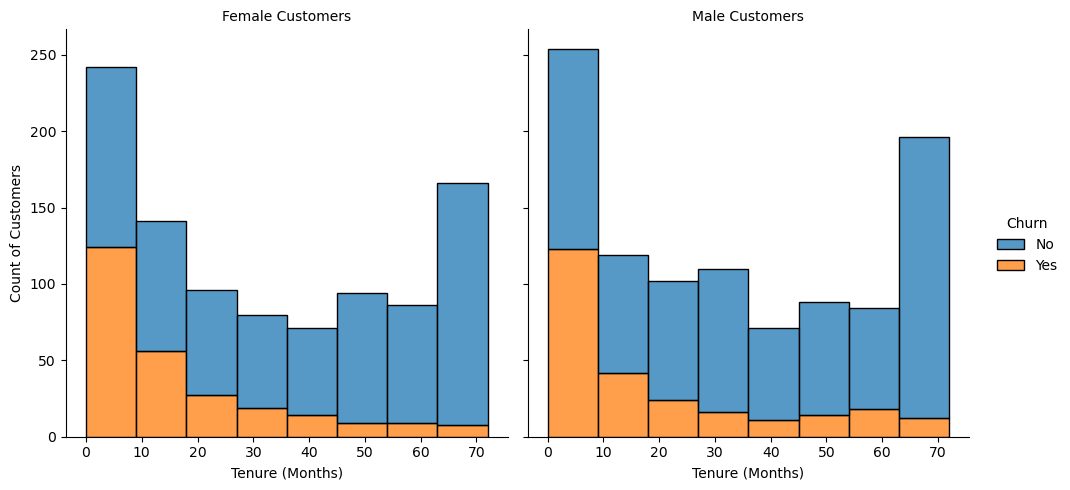

In [ ]:
g = sns.displot(data=visualization_df, x='tenure', hue='Churn', col='gender', multiple='stack', kind='hist',bins=8)
g.set_axis_labels("Tenure (Months)", "Count of Customers")
g.set_titles("{col_name} Customers")
plt.show()

# Bimodal distribution of tenure for churned vs non-churned customers, split by gender. 
# The customer base is mostly made up of brand new trial users and highly loyal long-term users, with fewer people in the middle. 
# The plot reveals that gender does not play a role in how long a customer stays or whether they choose to churn.

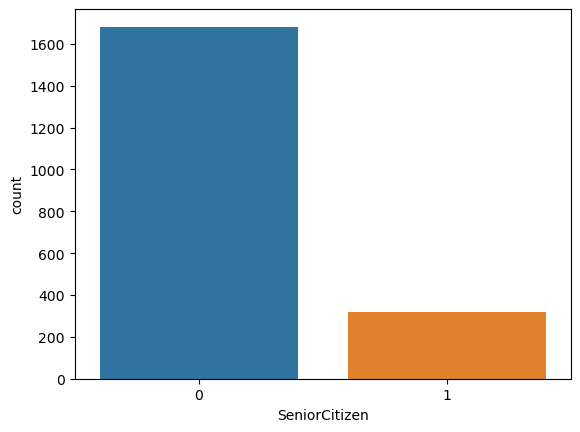

In [113]:
sns.countplot(data=visualization_df, x="SeniorCitizen")
plt.show()

/Users/mariapratyusha/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/mariapratyusha/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


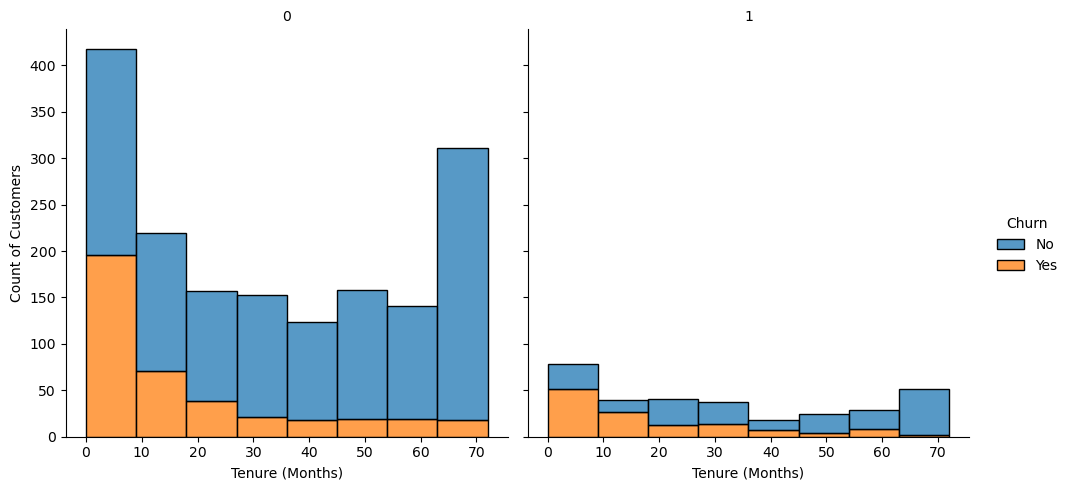

In [116]:
g = sns.displot(data=visualization_df, x='tenure', hue='Churn', col='SeniorCitizen', multiple='stack', kind='hist',bins=8)
g.set_axis_labels("Tenure (Months)", "Count of Customers")
g.set_titles("{col_name}")
plt.show()

#The Churn pattern is similar for both senior citizens and non-senior citizens, with most customers churning early in their tenure.

/Users/mariapratyusha/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/mariapratyusha/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


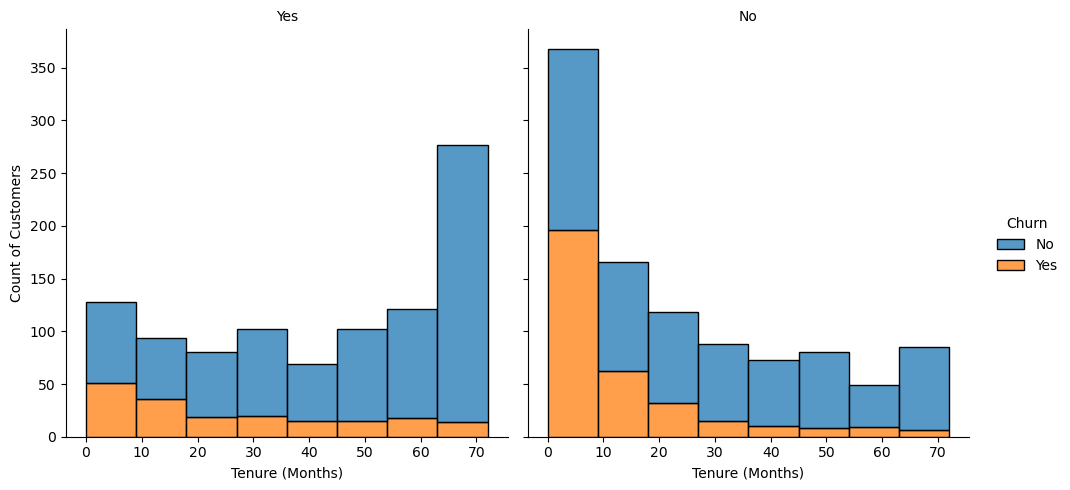

In [117]:
g = sns.displot(data=visualization_df, x='tenure', hue='Churn', col='Partner', multiple='stack', kind='hist',bins=8)
g.set_axis_labels("Tenure (Months)", "Count of Customers")
g.set_titles("{col_name}")
plt.show()

/Users/mariapratyusha/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/mariapratyusha/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


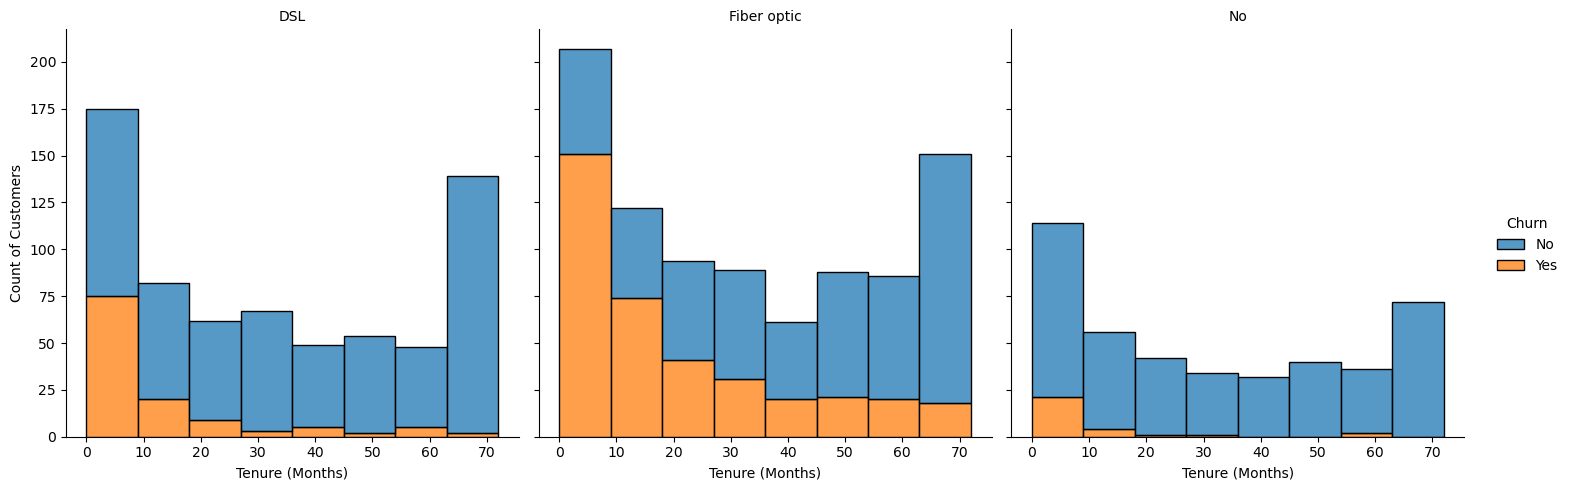

In [122]:
g = sns.displot(data=visualization_df, x='tenure', hue='Churn', col='InternetService', multiple='stack', kind='hist',bins=8)
g.set_axis_labels("Tenure (Months)", "Count of Customers")
g.set_titles("{col_name}")
plt.show()

/Users/mariapratyusha/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/mariapratyusha/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


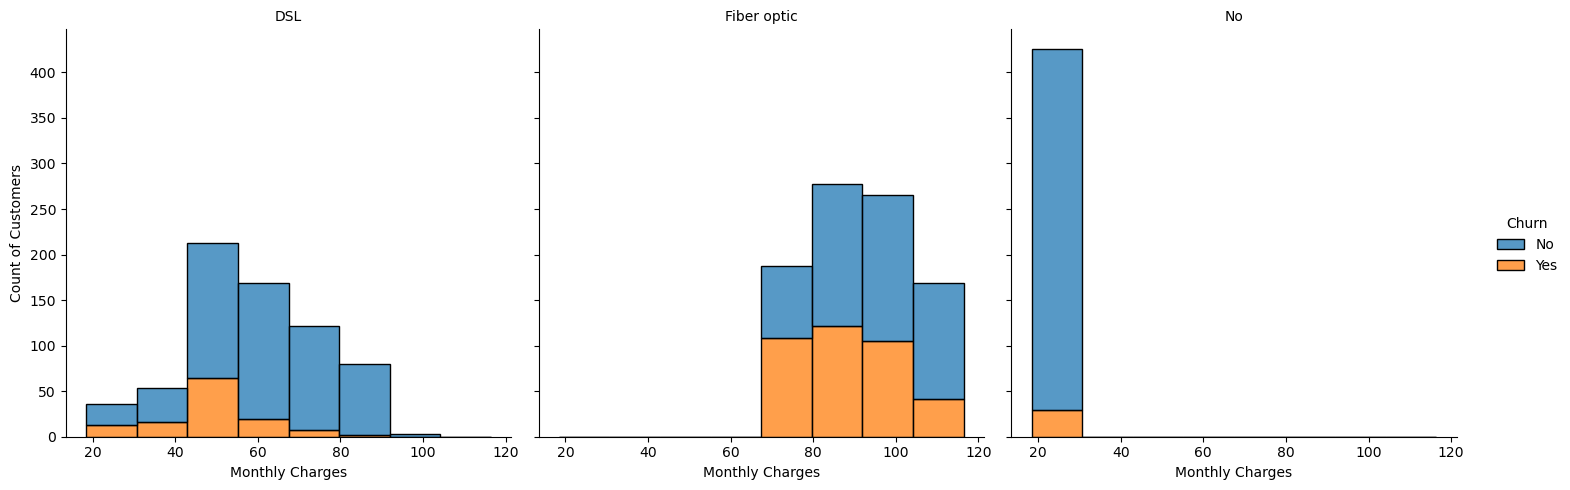

In [123]:
g = sns.displot(data=visualization_df, x='MonthlyCharges', hue='Churn', col='InternetService', multiple='stack', kind='hist',bins=8)
g.set_axis_labels("Monthly Charges", "Count of Customers")
g.set_titles("{col_name}")
plt.show()

/Users/mariapratyusha/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/mariapratyusha/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


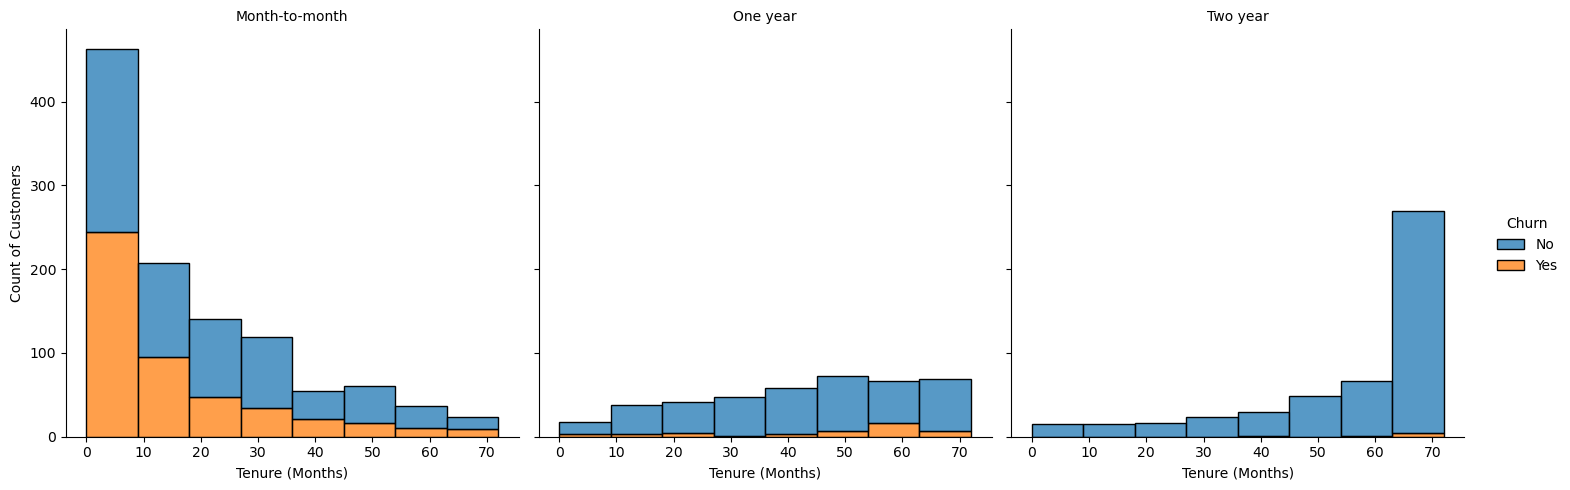

In [124]:
g = sns.displot(data=visualization_df, x='tenure', hue='Churn', col='Contract', multiple='stack', kind='hist',bins=8)
g.set_axis_labels("Tenure (Months)", "Count of Customers")
g.set_titles("{col_name}")
plt.show()

Text(0, 0.5, 'Frequency')

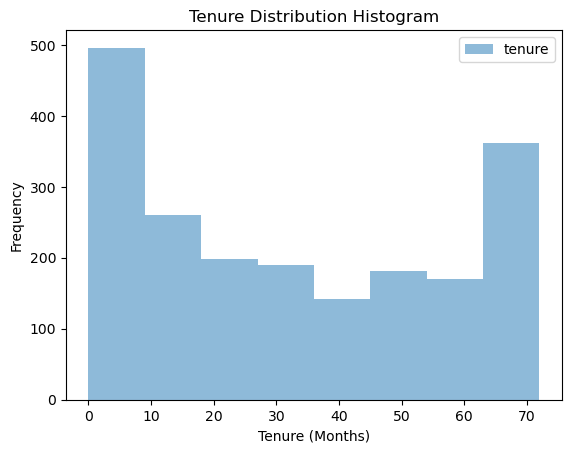

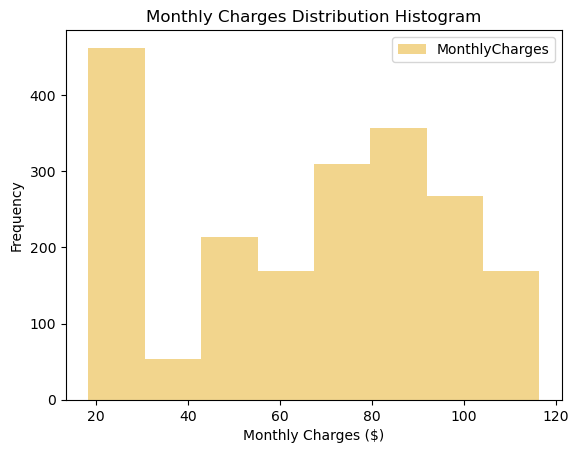

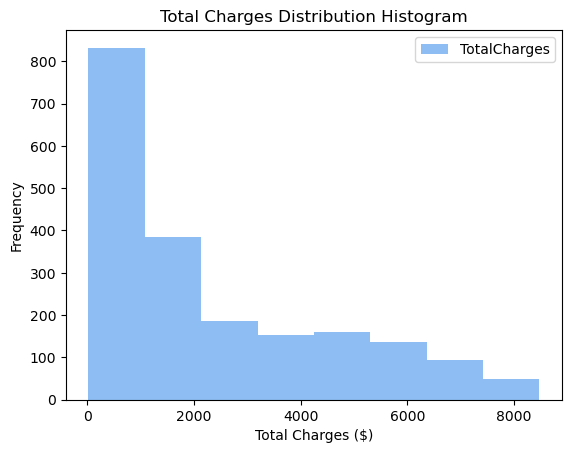

In [115]:
visualization_df.hist(column='tenure', bins=8, alpha=0.5, grid=False, legend=True)
plt.title("Tenure Distribution Histogram")
plt.xlabel("Tenure (Months)")
plt.ylabel("Frequency")

visualization_df.hist(column='MonthlyCharges', color="#E7AD1C", bins=8, alpha=0.5, grid=False, legend=True)
plt.title("Monthly Charges Distribution Histogram")
plt.xlabel("Monthly Charges ($)")
plt.ylabel("Frequency")

visualization_df.hist(column='TotalCharges', color="#1C7CE7", bins=8, alpha=0.5, grid=False, legend=True)
plt.title("Total Charges Distribution Histogram")
plt.xlabel("Total Charges ($)")
plt.ylabel("Frequency")

#### Lazy Preprocessing Pipeline

In [121]:
def unique_values_check(df):
    metrics = {
        "total_rows": 0,
        "unique_values": {col: set() for col in df.features},
    }

    #Streaming through the dataset to compute metrics
    #Single pass loop
    for row in df:
        metrics["total_rows"]+= 1
        for col in df.features: 
            value = row[col]
            metrics["unique_values"][col].add(value)

        

    #print(metrics)

    print("\n---STREAMING DIAGNOSTICS COMPLETED---")
    print(f"Total Dataset Rows Scaled: {metrics['total_rows']}")
    #print("Unique Values Found Per Column:")
    #for col, values in metrics["unique_values"].items():
       # print(f"\t{col}: {len(values)} unique values")

    for col, values in metrics["unique_values"].items():
            if len(values) < 10:
                print(f"\t{col} values: {list(values)[:]}")

unique_values_check(raw_stream)


---STREAMING DIAGNOSTICS COMPLETED---
Total Dataset Rows Scaled: 7043
	gender values: ['Female', 'Male']
	SeniorCitizen values: [0, 1]
	Partner values: ['No', 'Yes']
	Dependents values: ['No', 'Yes']
	PhoneService values: ['No', 'Yes']
	MultipleLines values: ['No', 'No phone service', 'Yes']
	InternetService values: ['No', 'DSL', 'Fiber optic']
	OnlineSecurity values: ['No', 'Yes', 'No internet service']
	OnlineBackup values: ['No', 'Yes', 'No internet service']
	DeviceProtection values: ['No', 'Yes', 'No internet service']
	TechSupport values: ['No', 'Yes', 'No internet service']
	StreamingTV values: ['No', 'Yes', 'No internet service']
	StreamingMovies values: ['No', 'Yes', 'No internet service']
	Contract values: ['One year', 'Month-to-month', 'Two year']
	PaperlessBilling values: ['No', 'Yes']
	PaymentMethod values: ['Bank transfer (automatic)', 'Electronic check', 'Credit card (automatic)', 'Mailed check']
	Churn values: ['No', 'Yes']


In [125]:
print("---LAZY PREPROCESSING PIPELINE---")

def production_pipeline(row):

    #Step 1: Imputation and type conversion for numeric columns
    
    val = row['TotalCharges']
    if val is None or str(val).strip().lower() in ["", "na", "nan", "null"]:
        row['TotalCharges'] = 0.0
    else:
        row['TotalCharges'] = float(val)

    row['MonthlyCharges'] = float(row['MonthlyCharges'])
    row['tenure'] = int(row['tenure'])

    #Step 2: Lazy Feature Engineering
    #Creating brand-new features using domain knowledge or insights from data exploration (EDA) to help the model find hidden patterns.

    #Step 2a: Customer Tenure Category
    if row['tenure'] <=12:
        row['customer_tenure_category'] = 'New'
    elif row['tenure'] <= 48:
        row['customer_tenure_category'] = 'Intermediate'
    else:
        row['customer_tenure_category'] = 'Loyal'

    #Step 2b: Additional Services Count
    addons = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
    row['total_addons_count'] = sum(1 for service in addons if row.get(service) == 'Yes')

    #Step 2c: High-Risk Interaction 
    row['is_high_risk_fiber'] = 1 if (row['InternetService'] == 'Fiber optic' and row['MonthlyCharges'] > 70.0) else 0

    #Step 2d: Financial Burden Ratio
    row['monthly_to_total_ratio'] = row['MonthlyCharges'] / (row['TotalCharges'] + 1.0)

    #Step 3: One-hot encoding for categorical columns
    #Feature Encoding: Converting existing text categories into numeric representations (0, 1, 2) without adding new information.

    #Binary Encoding
    row['gender_encoded'] = 1 if row['gender'] == 'Female' else 0
    row['partner_encoded'] = 1 if row['Partner'] == 'Yes' else 0
    row['dependents_encoded'] = 1 if row['Dependents'] == 'Yes' else 0
    row['phoneservice_encoded'] = 1 if row['PhoneService'] == 'Yes' else 0
    row['paperlessbilling_encoded'] = 1 if row['PaperlessBilling'] == 'Yes' else 0

    row['label'] = 1 if row['Churn'] == 'Yes' else 0

    #Multi-class Encoding
    multiplelines_map = {"No": 0, "Yes": 1, "No phone service": 2}
    row['multiplelines_encoded'] = multiplelines_map.get(row['MultipleLines'], 2)

    internet_map = {"DSL": 0, "Fiber optic": 1, "No": 2}
    row['internetservice_encoded'] = internet_map.get(row['InternetService'], 2)

    onlinesercurity_map = {"No": 0, "Yes": 1, "No internet service": 2}
    row['onlinesecurity_encoded'] = onlinesercurity_map.get(row['OnlineSecurity'], 2)

    onlinebackup_map = {"No": 0, "Yes": 1, "No internet service": 2}
    row['onlinebackup_encoded'] = onlinebackup_map.get(row['OnlineBackup'], 2)

    deviceprotection_map = {"No": 0, "Yes": 1, "No internet service": 2}
    row['deviceprotection_encoded'] = deviceprotection_map.get(row['DeviceProtection'], 2)

    techsupport_map = {"No": 0, "Yes": 1, "No internet service": 2}
    row['techsupport_encoded'] = techsupport_map.get(row['TechSupport'], 2)

    streamingtv_map = {"No": 0, "Yes": 1, "No internet service": 2}
    row['streamingtv_encoded'] = streamingtv_map.get(row['StreamingTV'], 2)

    streamingmovies_map = {"No": 0, "Yes": 1, "No internet service": 2}
    row['streamingmovies_encoded'] = streamingmovies_map.get(row['StreamingMovies'], 2)

    contract_map = {"Month-to-month": 0, "One year": 1, "Two year": 2}
    row['contract_encoded'] = contract_map.get(row['Contract'], 2)

    paymentmethod_map = {"Bank transfer (automatic)": 0, "Credit card": 1, "Electronic check": 2, "Mailed check": 3}
    row['paymentmethod_encoded'] = paymentmethod_map.get(row['PaymentMethod'], 3)

    customertenurecategory_map = {"New": 0, "Intermediate": 1, "Loyal": 2}
    row['customertenurecategory_encoded'] = customertenurecategory_map.get(row['customer_tenure_category'], 2)

    return row


updated_features = raw_stream.features.copy()

# Update the type conversions for the cleaned numeric columns
updated_features['TotalCharges'] = Value(dtype='float64')
updated_features['MonthlyCharges'] = Value(dtype='float64')
updated_features['tenure'] = Value(dtype='int64')

# New engineered features
updated_features['customer_tenure_category'] = Value(dtype='string')
updated_features['total_addons_count'] = Value(dtype='int64')
updated_features['is_high_risk_fiber'] = Value(dtype='int64')
updated_features['monthly_to_total_ratio'] = Value(dtype='float64')

# Multi-class and binary encoded column signatures
updated_features['label'] = Value(dtype='int64')
updated_features['gender_encoded'] = Value(dtype='int64')
updated_features['partner_encoded'] = Value(dtype='int64')
updated_features['dependents_encoded'] = Value(dtype='int64')
updated_features['phoneservice_encoded'] = Value(dtype='int64')
updated_features['paperlessbilling_encoded'] = Value(dtype='int64')
updated_features['multiplelines_encoded'] = Value(dtype='int64')
updated_features['internetservice_encoded'] = Value(dtype='int64')
updated_features['onlinesecurity_encoded'] = Value(dtype='int64')
updated_features['onlinebackup_encoded'] = Value(dtype='int64')
updated_features['deviceprotection_encoded'] = Value(dtype='int64')
updated_features['techsupport_encoded'] = Value(dtype='int64')
updated_features['streamingtv_encoded'] = Value(dtype='int64')
updated_features['streamingmovies_encoded'] = Value(dtype='int64')
updated_features['contract_encoded'] = Value(dtype='int64')
updated_features['paymentmethod_encoded'] = Value(dtype='int64')
updated_features['customertenurecategory_encoded'] = Value(dtype='int64')

#Complete blueprint mapping of the raw stream to the production pipeline with updated features
fully_processed_stream = raw_stream.map(production_pipeline, features=updated_features)


---LAZY PREPROCESSING PIPELINE---


In [128]:
print("--- TESTING RE-ENGINEERED PRODUCTION STREAM ---")
preview_row = next(iter(fully_processed_stream))

# Target specific new metrics to see if they calculate correctly
engineered_check = ['customerID', 'total_addons_count', 'is_high_risk_fiber', 'monthly_to_total_ratio', 'contract_encoded', 'label']
for col in engineered_check:
    print(f"{col:<25} : {preview_row[col]}")

--- TESTING RE-ENGINEERED PRODUCTION STREAM ---
customerID                : 7590-VHVEG
total_addons_count        : 1
is_high_risk_fiber        : 0
monthly_to_total_ratio    : 0.9675850891410048
contract_encoded          : 0
label                     : 0


In [130]:
fully_processed_stream

IterableDataset({
    features: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'customer_tenure_category', 'total_addons_count', 'is_high_risk_fiber', 'monthly_to_total_ratio', 'label', 'gender_encoded', 'partner_encoded', 'dependents_encoded', 'phoneservice_encoded', 'paperlessbilling_encoded', 'multiplelines_encoded', 'internetservice_encoded', 'onlinesecurity_encoded', 'onlinebackup_encoded', 'deviceprotection_encoded', 'techsupport_encoded', 'streamingtv_encoded', 'streamingmovies_encoded', 'contract_encoded', 'paymentmethod_encoded', 'customertenurecategory_encoded'],
    num_shards: 1
})

In [ ]:
#Selecting only the numerical features for model training. Categorical features will be handled separately in the model pipeline.

feature_columns = []

for col, col_type in fully_processed_stream.features.items():
    if col == 'label':
        continue
    if col_type.dtype in ['int64', 'float64']:
        feature_columns.append(col)

target_column = 'label'

print(f"Selected {len(feature_columns)} numerical features!")
print("Selected Columns:", feature_columns)

Selected 23 numerical features!
Selected Columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'total_addons_count', 'is_high_risk_fiber', 'monthly_to_total_ratio', 'gender_encoded', 'partner_encoded', 'dependents_encoded', 'phoneservice_encoded', 'paperlessbilling_encoded', 'multiplelines_encoded', 'internetservice_encoded', 'onlinesecurity_encoded', 'onlinebackup_encoded', 'deviceprotection_encoded', 'techsupport_encoded', 'streamingtv_encoded', 'streamingmovies_encoded', 'contract_encoded', 'paymentmethod_encoded', 'customertenurecategory_encoded']


In [133]:
#Creating ML Stream Converter

numpy_ready_stream = fully_processed_stream.with_format(None)

X_list = []
y_list = []

print("---STREAMING DATA CONVERSION TO NUMPY---")
for row in numpy_ready_stream:
    numeric_row = [float(row[col]) for col in feature_columns]
    X_list.append(numeric_row)
    y_list.append(float(row[target_column]))

X = np.array(X_list)
y = np.array(y_list)

print("\n---DATA MATRICES PREPARED---")
print(f"X matrix shape (Features): {X.shape} (Rows, Columns)")
print(f"y matrix shape (Target)  : {y.shape} (Labels)")

---STREAMING DATA CONVERSION TO NUMPY---

---DATA MATRICES PREPARED---
X matrix shape (Features): (7043, 23) (Rows, Columns)
y matrix shape (Target)  : (7043,) (Labels)


#### Production Testing Workflow Setup

In [142]:
#The dataset on Hugging Face is only has train. This section of the code is not used in this notebook. 

"""
raw_test_stream = load_dataset("sanjaycusat/telco-customer-churn3", streaming=True, split="test")

clean_test_stream = raw_test_stream.map(production_pipeline, features=updated_features)

X_test_list = []
y_test_list = []

for row in numpy_ready_stream:
    numeric_row = [float(row[col]) for col in feature_columns]
    X_test_list.append(numeric_row)
    y_test_list.append(float(row[target_column]))

X_test = np.array(X_test_list)
y_test = np.array(y_test_list)

print("\n---DATA MATRICES PREPARED FOR TESTING---")
print(f"X_test matrix shape (Features): {X_test.shape} (Rows, Columns)")
print(f"y_test matrix shape (Target)  : {y_test.shape} (Labels)")
"""


'\nraw_test_stream = load_dataset("sanjaycusat/telco-customer-churn3", streaming=True, split="test")\n\nclean_test_stream = raw_test_stream.map(production_pipeline, features=updated_features)\n\nX_test_list = []\ny_test_list = []\n\nfor row in numpy_ready_stream:\n    numeric_row = [float(row[col]) for col in feature_columns]\n    X_test_list.append(numeric_row)\n    y_test_list.append(float(row[target_column]))\n\nX_test = np.array(X_test_list)\ny_test = np.array(y_test_list)\n\nprint("\n---DATA MATRICES PREPARED FOR TESTING---")\nprint(f"X_test matrix shape (Features): {X_test.shape} (Rows, Columns)")\nprint(f"y_test matrix shape (Target)  : {y_test.shape} (Labels)")\n'

In [146]:
#First 80-20 split 
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Splitting the 80% training data into 80% training and 20% validation sets
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print("---RECONFIGURED 3-SET SPLIT COMPLETED---")
print(f"1. Training Set Matrix (X_train)   : {X_train.shape} -> Fit model weights here")
print(f"2. Validation Set Matrix (X_val)   : {X_val.shape}  -> Compare baseline algorithms here")
print(f"3. Final Test Set Matrix (X_test)   : {X_test.shape} -> Keep hidden until the very end!")

---RECONFIGURED 3-SET SPLIT COMPLETED---
1. Training Set Matrix (X_train)   : (4507, 23) -> Fit model weights here
2. Validation Set Matrix (X_val)   : (1127, 23)  -> Compare baseline algorithms here
3. Final Test Set Matrix (X_test)   : (1409, 23) -> Keep hidden until the very end!


In [149]:
print(X_test[:1], '\n\n', y_test[:1])
print(X_train[:1], '\n\n', y_train[:1])
print(X_val[:1], '\n\n', y_val[:1])

[[-0.43927126 -1.27622406 -1.33168614 -0.99486691 -1.10994555 -0.85214938
   0.3556381   1.03224813  1.03316562 -0.64563925 -3.04409507  0.8386452
   2.10946874 -1.17380634 -0.89871185 -1.01332629 -0.99465122 -0.90496803
  -1.07950498 -1.0829097  -0.82438878 -0.00831858 -1.26289226]] 

 [1.]
[[-0.43927126  1.43699484 -1.50976014 -0.47557991 -1.10994555 -0.85214938
  -0.1050311  -0.96875932 -0.96789903 -0.64563925  0.32850485  0.8386452
  -0.93386532  1.53294484  1.61244394  1.56912301  1.57507824  1.60963795
   1.55111353  1.5503107   0.38391048  0.86358424  1.27641419]] 

 [0.]
[[-0.43927126  1.10811982 -0.43632339  0.32690618  0.51249486 -0.85214938
  -0.10457056 -0.96875932 -0.96789903 -0.64563925 -3.04409507  0.8386452
   2.10946874 -1.17380634 -0.89871185 -1.01332629 -0.99465122  0.35233496
   0.23580428  0.2337005  -0.82438878 -0.00831858  1.27641419]] 

 [0.]


#### Model Training

##### Logistic Regression

/Users/mariapratyusha/anaconda3/lib/python3.11/site-packages/shap/explainers/_linear.py:123: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


[[-2.29829681e-02 -1.01461494e+00  8.82460580e-02 ...  5.64883311e-01
   5.06843430e-05 -2.84805127e-01]
 [-2.29829681e-02 -1.01461494e+00 -1.94532817e-01 ...  5.64883311e-01
   5.06843430e-05 -2.84805127e-01]
 [-2.29829681e-02  1.18498387e+00 -1.02900638e-01 ...  5.64883311e-01
   6.13843709e-04  3.41140208e-01]
 ...
 [-2.29829681e-02  2.25158933e-01 -2.69086597e-01 ... -2.19676843e-01
   5.06843430e-05  2.81675401e-02]
 [-2.29829681e-02 -6.54680593e-01 -9.50183000e-02 ... -1.00423700e+00
   6.13843709e-04 -2.84805127e-01]
 [-2.29829681e-02  1.22497658e+00  6.55843363e-02 ...  5.64883311e-01
   6.13843709e-04  3.41140208e-01]]


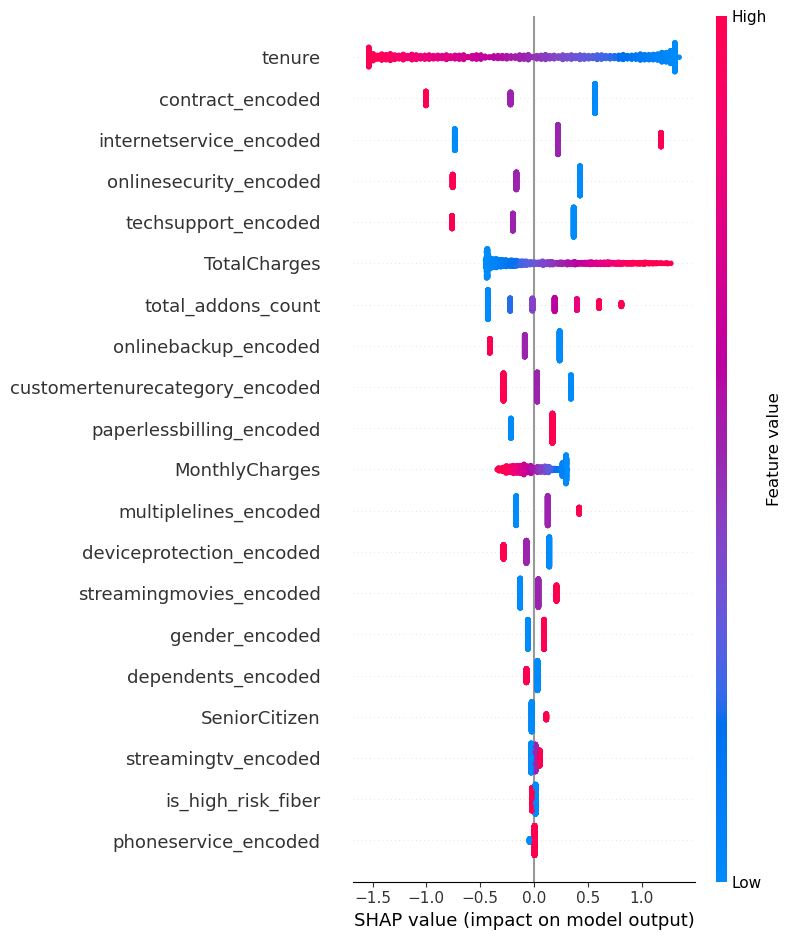

Validation prediction: [0. 0. 0. 1. 0.]
Validation probabilities: [0.14675192 0.22915317 0.47745128 0.56610827 0.04880152]
Validation accuracy: 0.7995
Classification report:               precision    recall  f1-score   support

         0.0       0.84      0.90      0.87       822
         1.0       0.66      0.53      0.59       305

    accuracy                           0.80      1127
   macro avg       0.75      0.71      0.73      1127
weighted avg       0.79      0.80      0.79      1127

Validation ROC-AUC Score: 0.8388


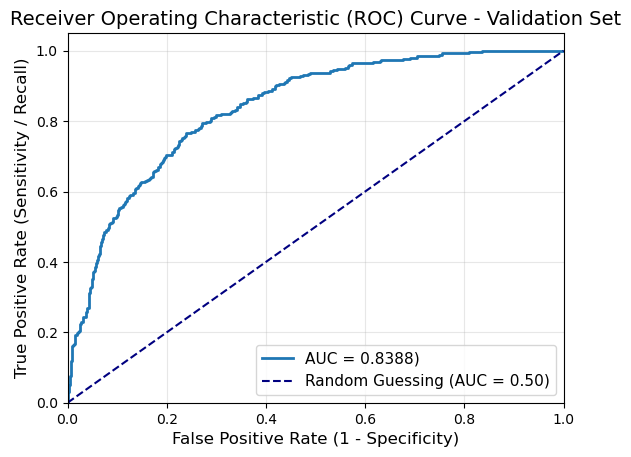

In [157]:
baseline_model = LogisticRegression(max_iter=1000, random_state=42)
baseline_model.fit(X_train, y_train)

val_pred = baseline_model.predict(X_val)
val_probs = baseline_model.predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val, val_probs)

explainer = shap.LinearExplainer(baseline_model, X_train, feature_perturbation="interventional")
shap_values = explainer.shap_values(X_val)

print(explainer)
print(shap_values)

shap.summary_plot(shap_values, X_val, feature_names=feature_columns)

#In case of models like XGBoost, LightGBM, or CatBoost, you can use TreeExplainer instead of LinearExplainer.
#explainer = shap.TreeExplainer(baseline_model)
#shap_values = explainer.shap_values(X_val[:300])

print(f"Validation prediction: {val_pred[:5]}")
print(f"Validation probabilities: {val_probs[:5]}")

print(f"Validation accuracy: {accuracy_score(y_val, val_pred):.4f}")
print(f"Classification report: {classification_report(y_val,val_pred)}")
print(f"Validation ROC-AUC Score: {auc:.4f}")

fpr, tpr, thresholds = roc_curve(y_val, val_probs)
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f})", lw=2)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--', label='Random Guessing (AUC = 0.50)')

# Graph customization
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve - Validation Set', fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)

# Render the plot in VS Code
plt.show()


In [ ]:
#SHAP
# Vertical Order (Importance): Features are ranked top-to-bottom by their global predictive power. 
# Horizontal Position (The Push): The vertical center line is 0.0. Points to the right of the line push the model to predict "Will Churn" (1). Points to the left push the model to predict "Will Stay" (0).
# Color (The Feature Value): Red represents a high value for that feature. Blue represents a low value. Purple represents mid-tier categorical codes or middle numbers.

#In this model, tenure is the absolute #1 most powerful feature, followed immediately by contract_encoded and internetservice_encoded. Columns at the bottom (like phoneservice_encoded) have almost zero impact.
#Higher tenure indicates lower churn risk. 

#ROC-AUC
# The Upper-Left Corner: The closer a model's line arcs toward the top-left corner of the grid, the better it is. It means the model is maximizing the True Positive Rate (catching actual churners) while keeping the False Positive Rate (false alarms) near zero.
# The Winner: Whichever model has the highest AUC value in the legend is your mathematically superior model across all thresholds.

##### Random Forest

.values =
array([[[ 0.00413811, -0.00413811],
        [ 0.01927128, -0.01927128],
        [ 0.01650091, -0.01650091],
        ...,
        [-0.07042106,  0.07042106],
        [-0.01151437,  0.01151437],
        [ 0.02939174, -0.02939174]],

       [[ 0.00186714, -0.00186714],
        [ 0.0439407 , -0.0439407 ],
        [-0.01926652,  0.01926652],
        ...,
        [-0.05680135,  0.05680135],
        [-0.01749414,  0.01749414],
        [ 0.04106875, -0.04106875]],

       [[ 0.00305943, -0.00305943],
        [-0.04600442,  0.04600442],
        [-0.03340193,  0.03340193],
        ...,
        [-0.06284454,  0.06284454],
        [ 0.02209993, -0.02209993],
        [-0.04358479,  0.04358479]],

       ...,

       [[ 0.00062067, -0.00062067],
        [ 0.01333405, -0.01333405],
        [-0.05493941,  0.05493941],
        ...,
        [ 0.09677956, -0.09677956],
        [-0.00666402,  0.00666402],
        [ 0.00280528, -0.00280528]],

       [[ 0.00367254, -0.00367254],
        [ 0.02409

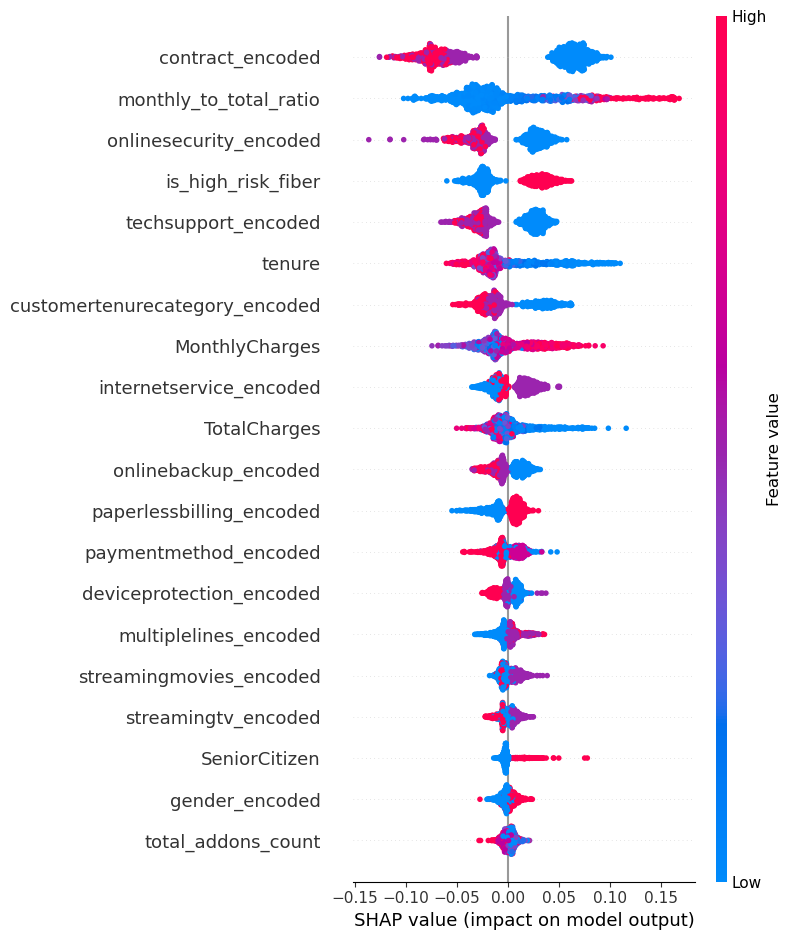

Validation prediction: [0. 0. 1. 1. 0.]
Validation probabilities: [0.23677913 0.21086792 0.56741764 0.54210977 0.05446677]
Validation accuracy: 0.7915
Classification report:               precision    recall  f1-score   support

         0.0       0.82      0.91      0.86       822
         1.0       0.66      0.48      0.55       305

    accuracy                           0.79      1127
   macro avg       0.74      0.69      0.71      1127
weighted avg       0.78      0.79      0.78      1127

Validation ROC-AUC Score: 0.8308


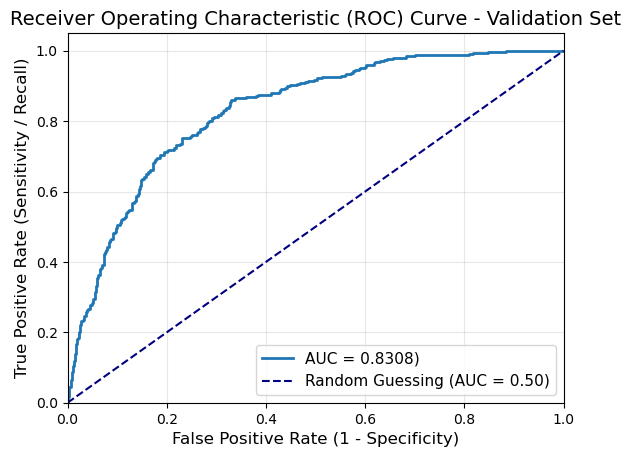

In [ ]:
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train, y_train)

val_pred = rf.predict(X_val)
val_probs = rf.predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val, val_probs)

explainer = shap.TreeExplainer(rf)
# shap_values = explainer.shap_values(X_val)
shap_values = explainer(X_val)

#Slice the object to target class 1 (Churn) across all rows and features to get the most prominent features when plotting
shap_churn = shap_values[:, :, 1]

print(explainer)
print(shap_values)
print(shap_churn)

shap.summary_plot(shap_churn, X_val, feature_names=feature_columns) 


print(f"Validation prediction: {val_pred[:5]}")
print(f"Validation probabilities: {val_probs[:5]}")

print(f"Validation accuracy: {accuracy_score(y_val, val_pred):.4f}")
print(f"Classification report: {classification_report(y_val,val_pred)}")
print(f"Validation ROC-AUC Score: {auc:.4f}")

fpr, tpr, thresholds = roc_curve(y_val, val_probs)
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f})", lw=2)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--', label='Random Guessing (AUC = 0.50)')

# Graph customization
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve - Validation Set', fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)

plt.show()

##### XGBoost

[[-0.00726418  0.12247425 -0.25017303 ...  0.53196466  0.17277758
   0.        ]
 [-0.00675531 -0.0518703   0.17397389 ...  0.46042982  0.2134727
   0.        ]
 [-0.01846738  0.03436567  0.18319897 ...  0.73285097 -0.1926017
   0.        ]
 ...
 [-0.01206893  0.0019715   0.6470894  ... -0.6270513   0.09894038
   0.        ]
 [-0.02161095 -0.05396396 -0.3183743  ... -1.9550067  -0.03657336
   0.        ]
 [-0.01565541  0.07524887 -0.21292205 ...  0.68443674 -0.07329002
   0.        ]]


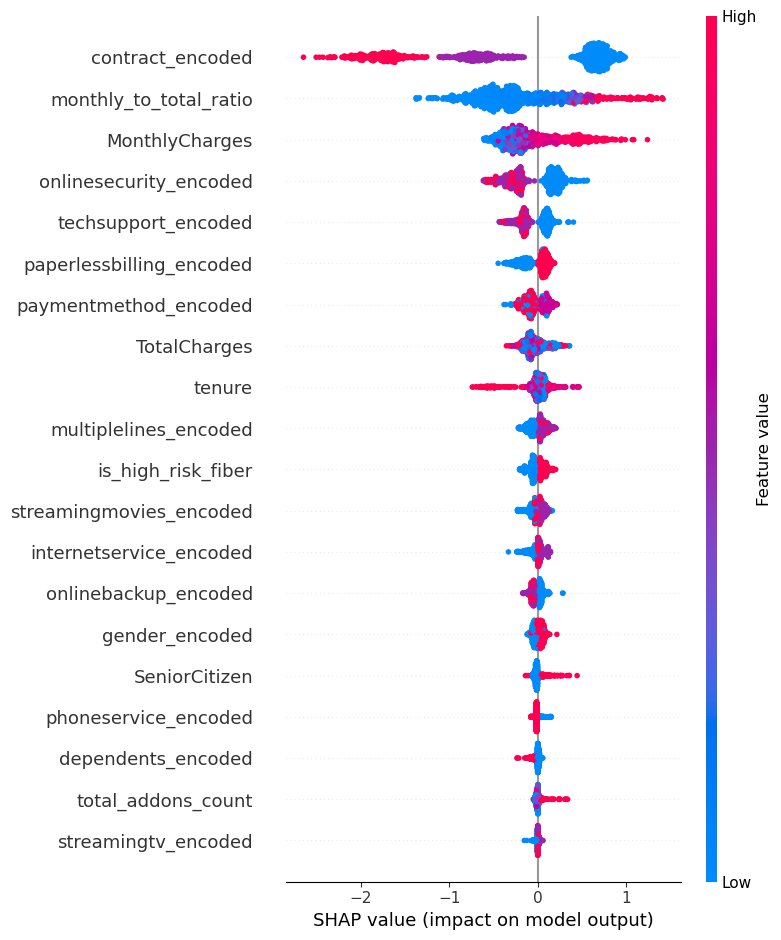

Validation prediction: [0 0 0 1 0]
Validation probabilities: [0.18947569 0.15901498 0.49323365 0.53673166 0.02363897]
Validation accuracy: 0.7950
Classification report:               precision    recall  f1-score   support

         0.0       0.83      0.90      0.87       822
         1.0       0.66      0.50      0.57       305

    accuracy                           0.80      1127
   macro avg       0.74      0.70      0.72      1127
weighted avg       0.78      0.80      0.79      1127

Validation ROC-AUC Score: 0.8345


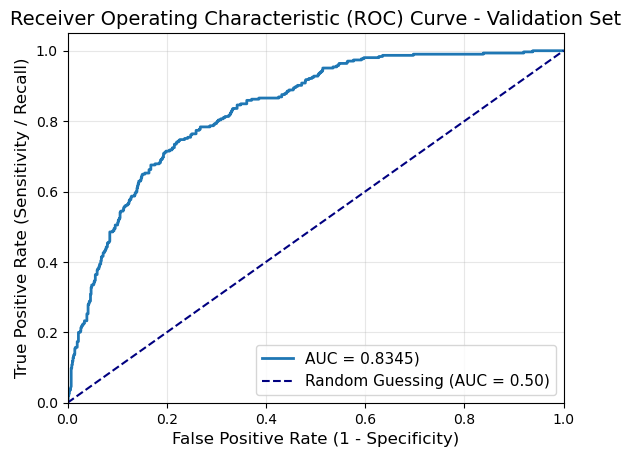

In [ ]:
xgb = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.05, random_state=42, eval_metric='logloss')
xgb.fit(X_train, y_train)

val_pred = xgb.predict(X_val)
val_probs = xgb.predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val, val_probs)

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_val)

print(explainer)
print(shap_values)
#print(shap_churn)

shap.summary_plot(shap_values, X_val, feature_names=feature_columns) 


print(f"Validation prediction: {val_pred[:5]}")
print(f"Validation probabilities: {val_probs[:5]}")

print(f"Validation accuracy: {accuracy_score(y_val, val_pred):.4f}")
print(f"Classification report: {classification_report(y_val,val_pred)}")
print(f"Validation ROC-AUC Score: {auc:.4f}")

fpr, tpr, thresholds = roc_curve(y_val, val_probs)
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}", lw=2)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--', label='Random Guessing (AUC = 0.50)')

# Graph customization
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve - Validation Set', fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)

plt.show()

##### LightGBM

/Users/mariapratyusha/anaconda3/lib/python3.11/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


[[-1.05002106e-02  6.63107430e-02 -1.57510715e-01 ...  8.32179305e-01
   1.52073740e-01  0.00000000e+00]
 [-2.46922634e-03 -2.79986881e-02  2.69410453e-01 ...  6.83148394e-01
   1.69365844e-01  0.00000000e+00]
 [-1.62879353e-02  6.02075143e-02  1.82493127e-01 ...  1.20540614e+00
  -1.69585410e-01  0.00000000e+00]
 ...
 [-1.00055215e-02 -2.54641826e-02  7.30219996e-01 ... -3.97172373e-01
   9.05389924e-02  0.00000000e+00]
 [-2.85035629e-02 -1.12748425e-03 -2.03818642e-01 ... -1.52368019e+00
  -7.72633692e-02  0.00000000e+00]
 [-1.68862883e-02  9.82863952e-02 -1.56586082e-01 ...  1.12953697e+00
  -9.91390777e-02  0.00000000e+00]]


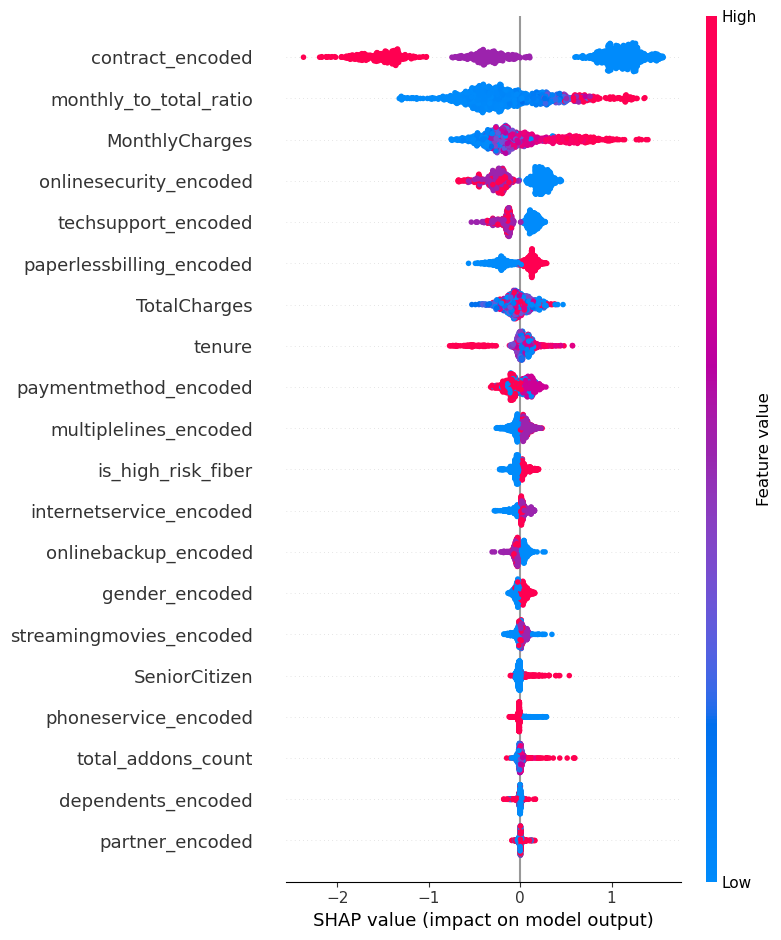

Validation prediction: [0. 0. 1. 1. 0.]
Validation probabilities: [0.16705398 0.10369733 0.54555085 0.65704531 0.01943201]
Validation accuracy: 0.8012
Classification report:               precision    recall  f1-score   support

         0.0       0.84      0.90      0.87       822
         1.0       0.66      0.54      0.59       305

    accuracy                           0.80      1127
   macro avg       0.75      0.72      0.73      1127
weighted avg       0.79      0.80      0.79      1127

Validation ROC-AUC Score: 0.8331


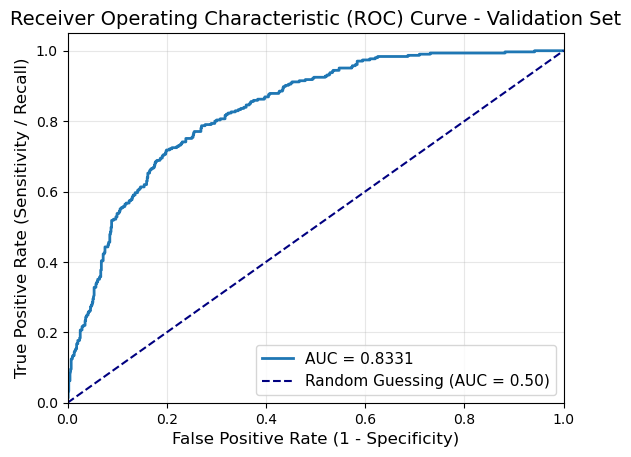

In [172]:
lgbm = LGBMClassifier(n_estimators=100,learning_rate=0.05, random_state=42, verbose=-1)
lgbm.fit(X_train, y_train)

val_pred = lgbm.predict(X_val)
val_probs = lgbm.predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val, val_probs)

explainer = shap.TreeExplainer(lgbm)
shap_values = explainer.shap_values(X_val)

print(explainer)
print(shap_values)
#print(shap_churn)

shap.summary_plot(shap_values, X_val, feature_names=feature_columns) 


print(f"Validation prediction: {val_pred[:5]}")
print(f"Validation probabilities: {val_probs[:5]}")

print(f"Validation accuracy: {accuracy_score(y_val, val_pred):.4f}")
print(f"Classification report: {classification_report(y_val,val_pred)}")
print(f"Validation ROC-AUC Score: {auc:.4f}")

fpr, tpr, thresholds = roc_curve(y_val, val_probs)
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}", lw=2)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--', label='Random Guessing (AUC = 0.50)')

# Graph customization
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve - Validation Set', fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)

plt.show()

##### Support Vector Machine (RBF)

  0%|          | 0/50 [00:00<?, ?it/s]

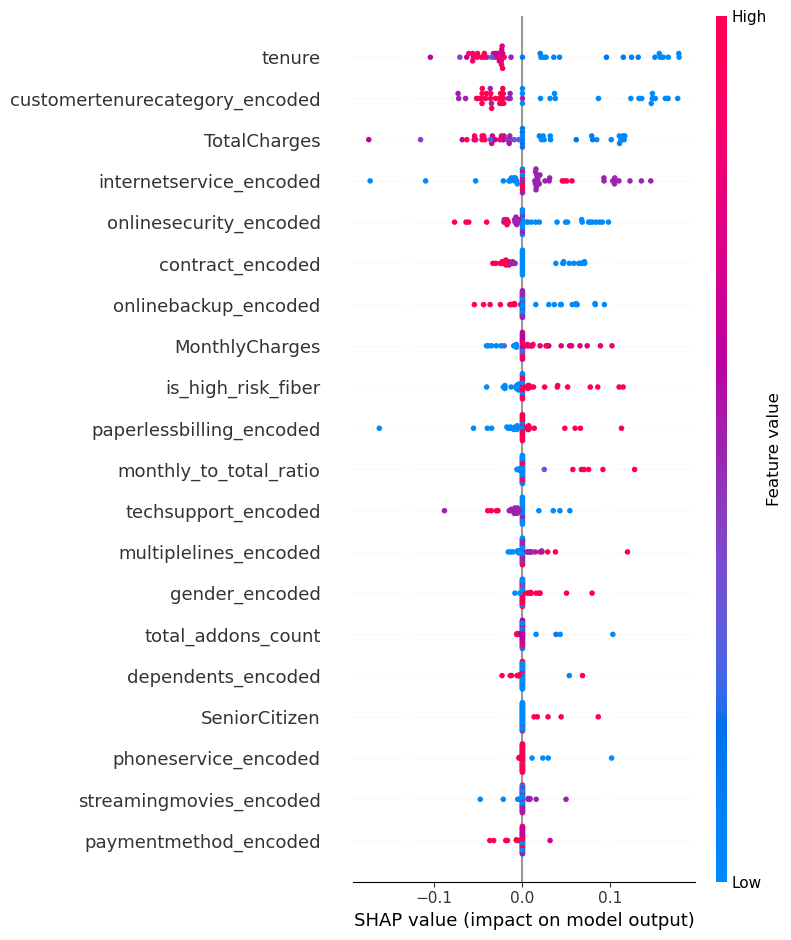

Validation prediction: [0. 0. 1. 0. 0.]
Validation probabilities: [0.13246723 0.15835351 0.51059251 0.30638698 0.07799226]
Validation accuracy: 0.7879
Classification report:               precision    recall  f1-score   support

         0.0       0.81      0.93      0.86       822
         1.0       0.68      0.41      0.51       305

    accuracy                           0.79      1127
   macro avg       0.74      0.67      0.69      1127
weighted avg       0.77      0.79      0.77      1127

Validation ROC-AUC Score: 0.7901


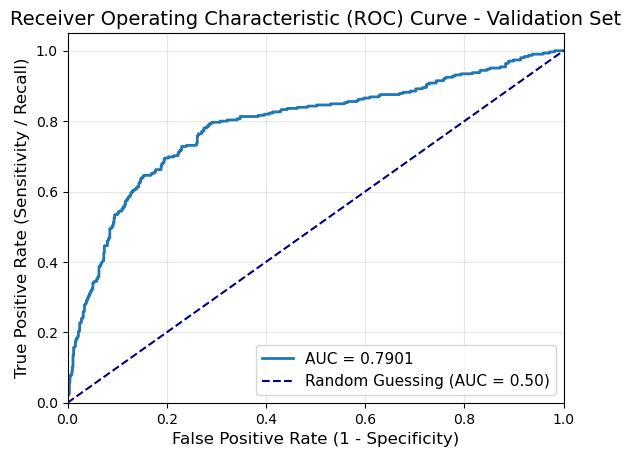

In [176]:
svm = SVC(kernel='rbf', C=1.0, probability=True, random_state=42)
svm.fit(X_train, y_train)

val_pred = svm.predict(X_val)
val_probs = svm.predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val, val_probs)

background_sample = X_train[:50] 

explainer = shap.KernelExplainer(svm.predict, background_sample)
shap_values = explainer.shap_values(X_val[:50])

shap.summary_plot(shap_values, X_val[:50], feature_names=feature_columns)


print(f"Validation prediction: {val_pred[:5]}")
print(f"Validation probabilities: {val_probs[:5]}")

print(f"Validation accuracy: {accuracy_score(y_val, val_pred):.4f}")
print(f"Classification report: {classification_report(y_val,val_pred)}")
print(f"Validation ROC-AUC Score: {auc:.4f}")

fpr, tpr, thresholds = roc_curve(y_val, val_probs)
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}", lw=2)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--', label='Random Guessing (AUC = 0.50)')

# Graph customization
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve - Validation Set', fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)

plt.show()

##### Balanced XGBoost

[[-0.00339838  0.11306612 -0.2714254  ...  0.50596493  0.17806493
   0.        ]
 [ 0.01223211 -0.06407574  0.21041067 ...  0.4456055   0.22574772
   0.        ]
 [-0.01546764  0.04957347  0.12302817 ...  0.72660613 -0.20835042
   0.        ]
 ...
 [ 0.00444422 -0.02487228  0.66523314 ... -0.6822805   0.11053179
   0.        ]
 [-0.02882831 -0.083785   -0.34143883 ... -1.9376643  -0.03373283
   0.        ]
 [-0.01903125  0.07178967 -0.21577829 ...  0.6926551  -0.13160478
   0.        ]]


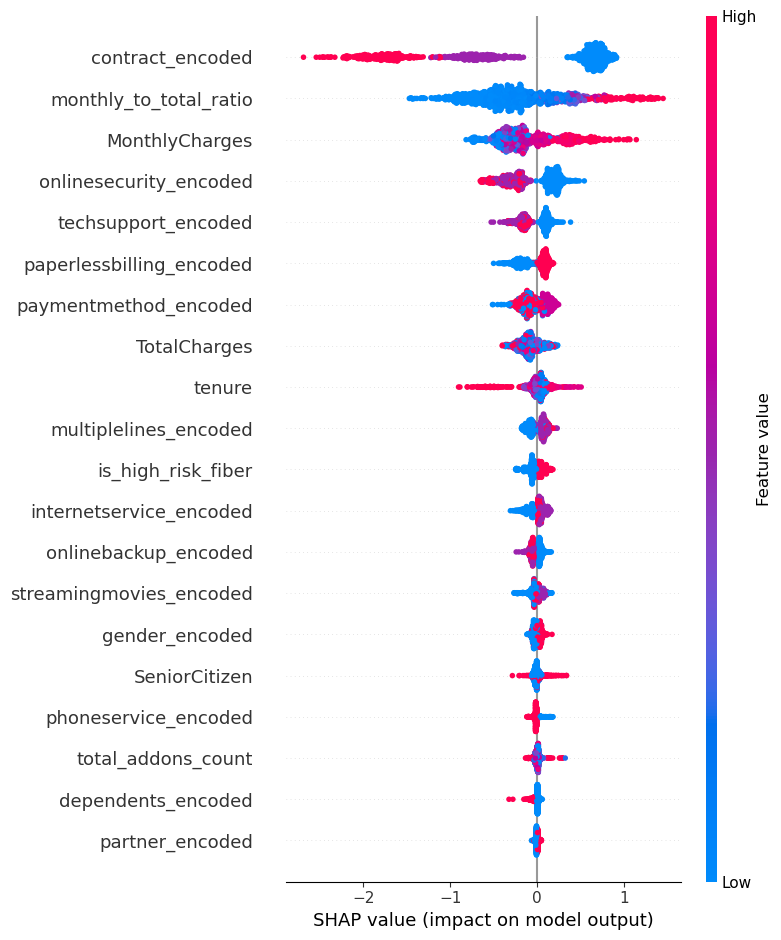

Validation prediction: [0 0 1 1 0]
Validation probabilities: [0.28961226 0.36534348 0.71598476 0.770433   0.04233396]
Validation accuracy: 0.7560
Classification report:               precision    recall  f1-score   support

         0.0       0.89      0.76      0.82       822
         1.0       0.54      0.73      0.62       305

    accuracy                           0.76      1127
   macro avg       0.71      0.75      0.72      1127
weighted avg       0.79      0.76      0.77      1127

Validation ROC-AUC Score: 0.8345


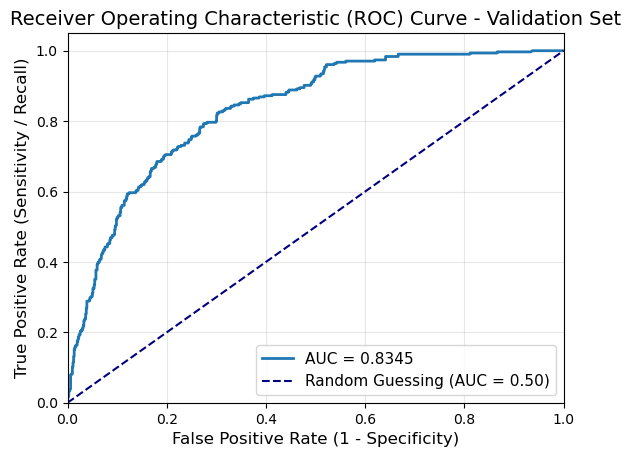

In [178]:
# Calculate the imbalance scale factor: total_negative_class / total_positive_class
# From the data: 822 (retained) / 305 (churned) = ~2.69
imbalance_ratio = 822.0 / 305.0

bxgb = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.05, scale_pos_weight=imbalance_ratio,random_state=42, eval_metric='logloss')
bxgb.fit(X_train, y_train)

val_pred = bxgb.predict(X_val)
val_probs = bxgb.predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val, val_probs)

explainer = shap.TreeExplainer(bxgb)
shap_values = explainer.shap_values(X_val)

print(explainer)
print(shap_values)
#print(shap_churn)

shap.summary_plot(shap_values, X_val, feature_names=feature_columns) 


print(f"Validation prediction: {val_pred[:5]}")
print(f"Validation probabilities: {val_probs[:5]}")

print(f"Validation accuracy: {accuracy_score(y_val, val_pred):.4f}")
print(f"Classification report: {classification_report(y_val,val_pred)}")
print(f"Validation ROC-AUC Score: {auc:.4f}")

fpr, tpr, thresholds = roc_curve(y_val, val_probs)
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}", lw=2)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--', label='Random Guessing (AUC = 0.50)')

# Graph customization
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve - Validation Set', fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)

plt.show()

#### Final Test Evaluation

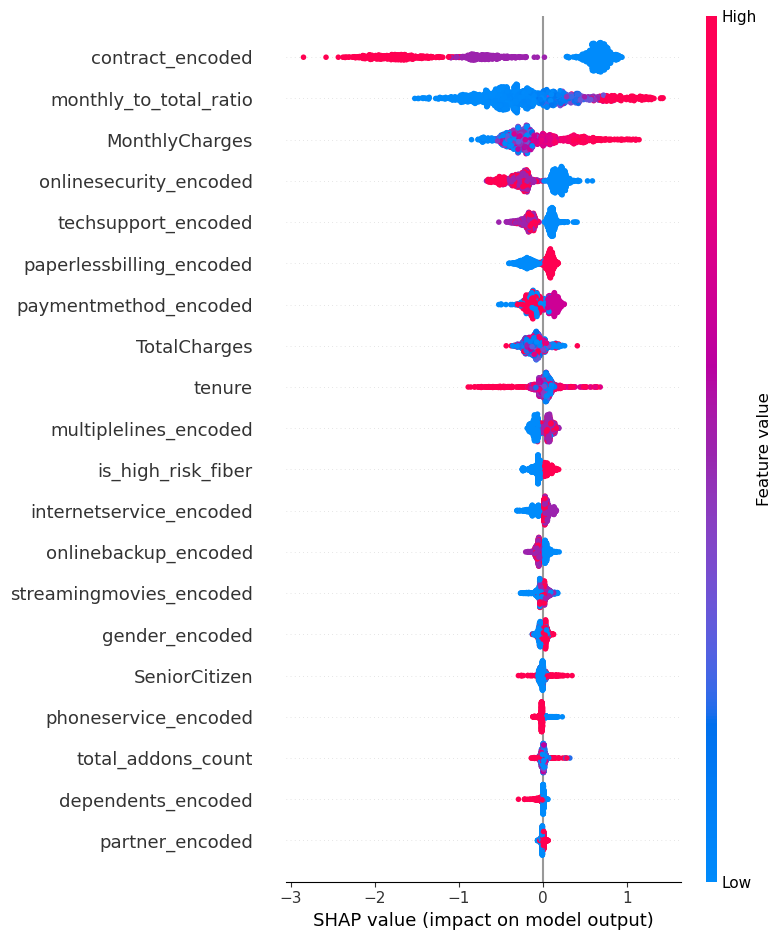

Production Test Accuracy: 0.7679
Production Classification report:               precision    recall  f1-score   support

         0.0       0.92      0.75      0.83      1036
         1.0       0.54      0.81      0.65       373

    accuracy                           0.77      1409
   macro avg       0.73      0.78      0.74      1409
weighted avg       0.82      0.77      0.78      1409

Production Test ROC-AUC Score: 0.8618


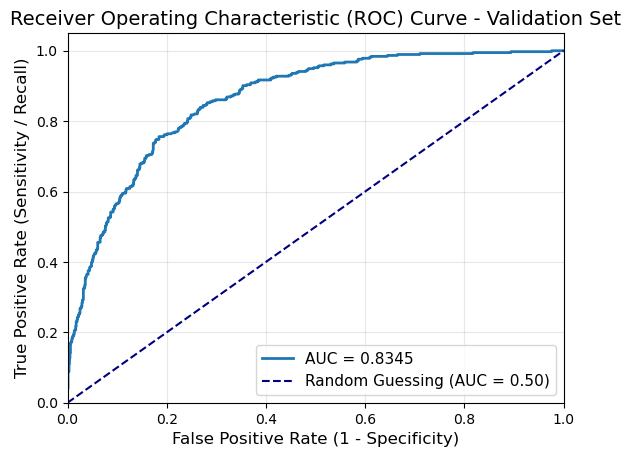

In [179]:
test_pred = bxgb.predict(X_test)
test_probs = bxgb.predict_proba(X_test)[:, 1]

test_auc = roc_auc_score(y_test, test_probs)

test_explainer = shap.TreeExplainer(bxgb)
test_shap_values = explainer.shap_values(X_test)

shap.summary_plot(test_shap_values, X_test, feature_names=feature_columns) 


print(f"Production Test Accuracy: {accuracy_score(y_test, test_pred):.4f}")
print(f"Production Classification report: {classification_report(y_test,test_pred)}")
print(f"Production Test ROC-AUC Score: {test_auc:.4f}")

test_fpr, test_tpr, test_thresholds = roc_curve(y_test, test_probs)
plt.plot(test_fpr, test_tpr, label=f"AUC = {auc:.4f}", lw=2)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--', label='Random Guessing (AUC = 0.50)')

# Graph customization
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve - Validation Set', fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)

plt.show()